In [1]:
import nilearn as nl
import numpy as np
import matplotlib
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import openpyxl as xl

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix, plot_contrast_matrix
from nilearn.glm.first_level import FirstLevelModel
from nilearn.masking import compute_epi_mask, apply_mask, unmask
from nilearn.image import index_img, resample_to_img, math_img, mean_img, get_data
from nilearn.plotting import plot_stat_map, show
from nilearn import image, masking
from nilearn import plotting
from nilearn.datasets import load_mni152_brain_mask
from pandas import read_excel

from nilearn.glm.second_level import SecondLevelModel
from scipy.stats import norm

from nilearn.glm import threshold_stats_img
from pathlib import Path
from atlasreader import create_output
from scipy.ndimage import label

from nilearn import datasets
from mpl_toolkits.axes_grid1 import make_axes_locatable
mni = datasets.load_mni152_template()

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



In [2]:
whichVersion = 'persentence' #persentence, 3sec, 6sec

stories = ["tunnel","21styear"]

base_dir1 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
)

save_dir = Path(f"{base_dir1}/moral_nonmoral/")

In [3]:
# Collect z-maps
output_dir_virtues = Path(f"{base_dir1}/virtues/fcontrast/")
output_dir_vices = Path(f"{base_dir1}/vices/fcontrast/")

all_output_dirs = [output_dir_virtues, output_dir_vices]

z_maps = []

for output_dir in all_output_dirs:
    for story in stories:
        z_map_path = output_dir / story / "zscores_fcontrast_secondlevel.nii.gz"
        
        if z_map_path.exists():
            print(f"✅ Loaded {z_map_path}")
            z_maps.append(image.load_img(z_map_path))
        else:
            print(f"⚠️ Missing: {z_map_path}")


# Resample all to the first image’s space
target_img = z_maps[0]
z_maps_resampled = [image.resample_to_img(img, target_img, interpolation="continuous") for img in z_maps]

# Create dictionary dynamically
img_dict = {f"img{i+1}": z_maps_resampled[i] for i in range(len(z_maps_resampled))}
expr = "np.minimum.reduce((" + ", ".join(img_dict.keys()) + "))"

# Compute conjunction map
min_stat_map = image.math_img(expr, **img_dict)

# Save output
output_path = os.path.join(save_dir, "minimum_stat_conjunction.nii.gz")
min_stat_map.to_filename(output_path)
print(f"✅ Saved conjunction map to: {output_path}")

✅ Loaded /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/tunnel/zscores_fcontrast_secondlevel.nii.gz
✅ Loaded /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/virtues/fcontrast/21styear/zscores_fcontrast_secondlevel.nii.gz
✅ Loaded /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/vices/fcontrast/tunnel/zscores_fcontrast_secondlevel.nii.gz
✅ Loaded /Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_val

/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_14121/1786832920.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  z_maps_resampled = [image.resample_to_img(img, target_img, interpolation="continuous") for img in z_maps]
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


In [4]:

thresholded_map, threshold = threshold_stats_img(
    stat_img=min_stat_map,
    alpha=0.05,            # FDR level (start here)
    height_control='fdr',  # use 'bonferroni' for more conservative FWER control
    cluster_threshold=0,   # use >0 to filter small clusters
    two_sided=True        # or True if you want two-sided test
)

print(threshold)

output_path = os.path.join(save_dir, "min_stat_conjunction_fdrcorrected.nii.gz")
thresholded_map.to_filename(output_path)

3.270614277991904


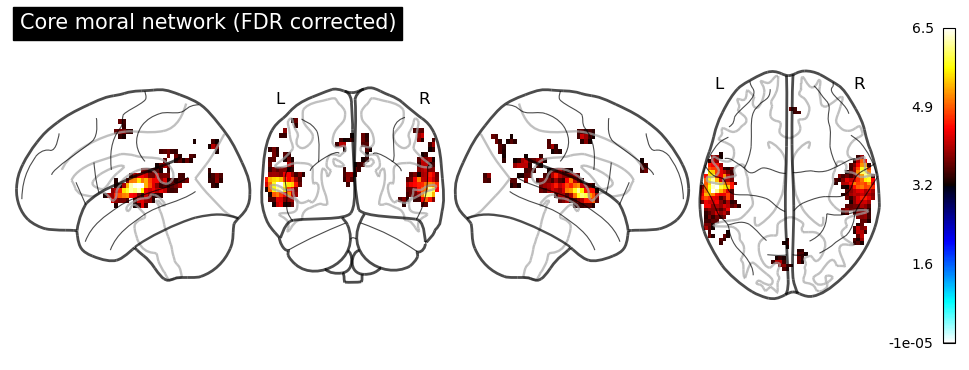

In [5]:
# glass brain 5+ voxels
load_fdr_image = os.path.join(save_dir, "min_stat_conjunction_fdrcorrected.nii.gz")
stat_img = image.load_img(load_fdr_image)

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 5:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

filtered_img.to_filename(os.path.join(save_dir, "filtered_clusters_5vox.nii.gz"))

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='Core moral network (FDR corrected)'
)


# Save as PNG
display.savefig(str(save_dir)+'/glass_brain_clusters_min5vox.png', dpi=300)  

In [6]:
output_path3 = os.path.join(save_dir, "min_stat_conjunction_fdrcorrected.nii.gz")

create_output(
        output_path3,
        cluster_extent=5,
        direction="pos",
        outdir=str(save_dir)
    )

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


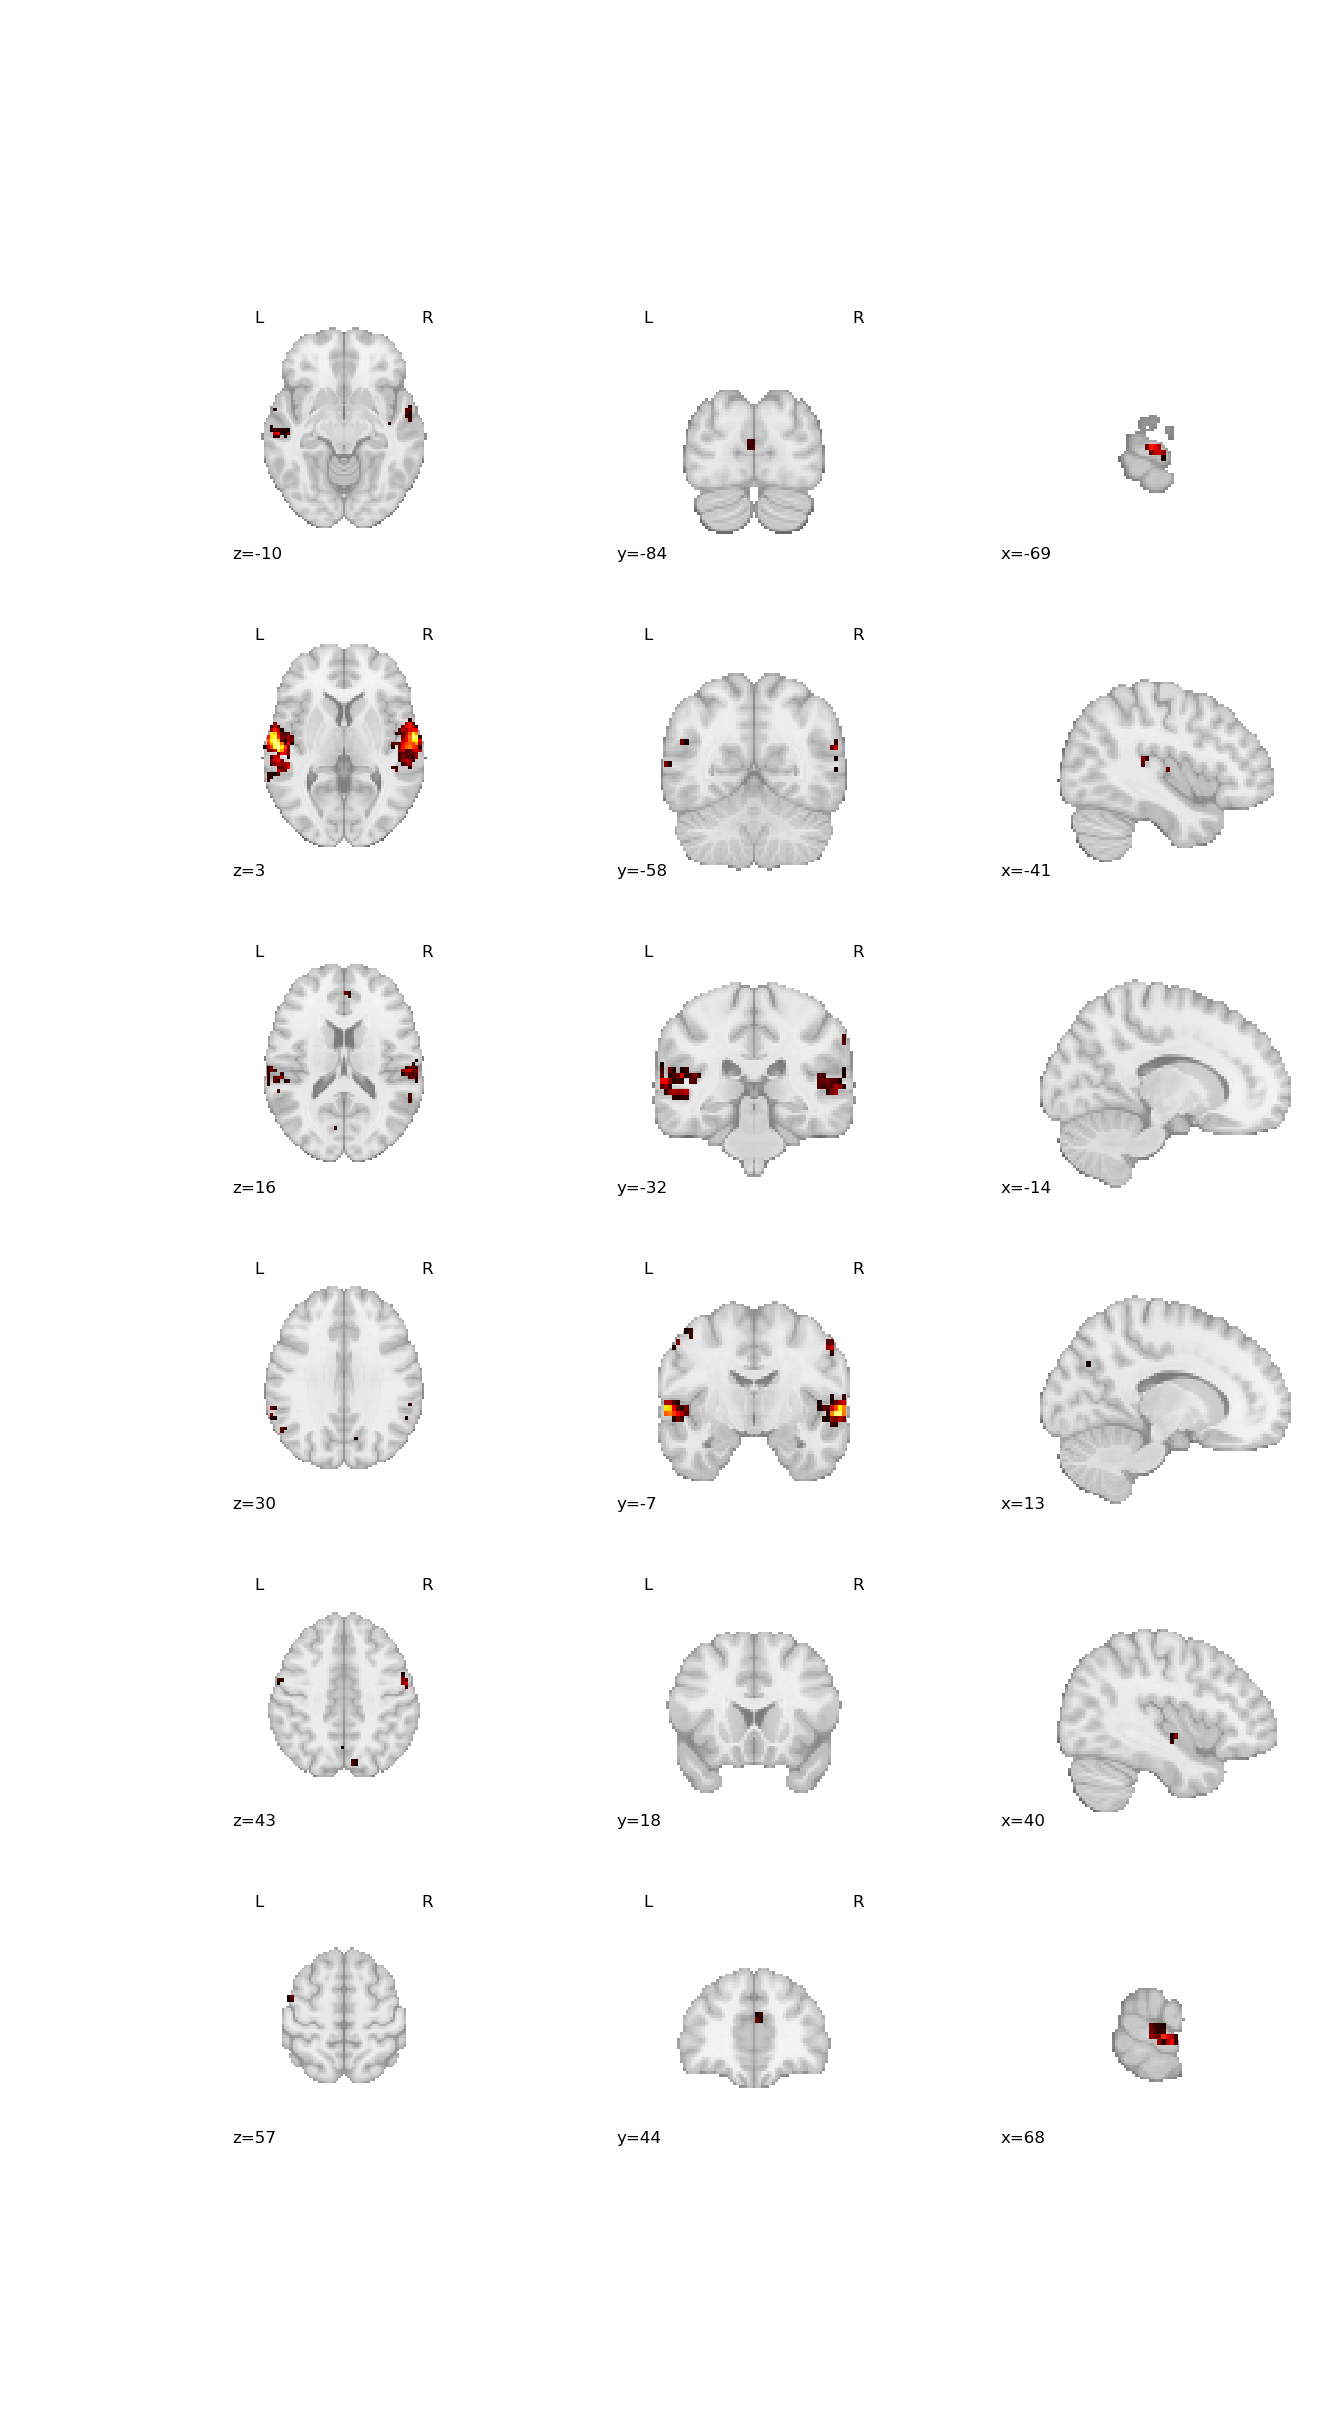

In [28]:
# Load filtered image
load_fdr_image = os.path.join(save_dir, "filtered_clusters_5vox.nii.gz")
filtered_img = image.load_img(load_fdr_image)
data = filtered_img.get_fdata()

# Extract voxel coords from already-filtered image
voxel_coords = np.array(np.where(data > 0)).T

# --- Slice selection ---
n_slices = 6
shape = filtered_img.shape
affine = filtered_img.affine
axis_map = {'x': 0, 'y': 1, 'z': 2}

def pick_slices(voxel_coords, axis, n_slices):
    all_coords = np.array([v[axis_map[axis]] for v in voxel_coords])
    slices = np.linspace(all_coords.min(), all_coords.max(), n_slices)
    return slices

coords = {}
for axis in ['x', 'y', 'z']:
    slice_voxels = pick_slices(voxel_coords, axis, n_slices)
    coords[axis] = [
        np.dot(affine, [c if axis_map[axis] == i else 0 for i in range(3)] + [1])[axis_map[axis]]
        for c in slice_voxels
    ]


# # --- Create figure with axes in columns ---
# fig, axes = plt.subplots(n_slices, 3, figsize=(18, 4*n_slices))

# for j, axis in enumerate(['z', 'y', 'x']):
#     for i, coord in enumerate(coords[axis]):
#         plotting.plot_stat_map(
#             filtered_img,
#             display_mode=axis,
#             cut_coords=[coord],
#             colorbar=False,
#             cmap='cold_hot',
#             axes=axes[i, j],
#             draw_cross=True,
#         )
#         axes[i, j].set_facecolor('white')

# fig.suptitle('Core moral network (FDR corrected)', fontsize=18)

# # Reduce spacing between subplots
# plt.subplots_adjust(wspace=0.01, hspace=0.01)

# # Save with minimal whitespace
# fig.savefig(
#     os.path.join(save_dir, 'multi_slices_columns_5voxelClusters.png'),
#     dpi=300,
#     bbox_inches='tight',   # key: tight boundaries
#     pad_inches=0           # no extra border
# )

fig, axes = plt.subplots(n_slices, 3, figsize=(15, 4*n_slices))

last_im = None

# --- Plotting ---
for j, axis in enumerate(['z','y','x']):
    for i, coord in enumerate(coords[axis]):

        display = plotting.plot_stat_map(
            filtered_img,
            display_mode=axis,
            cut_coords=[coord],
            colorbar=False,
            cmap='cold_hot',
            axes=axes[i, j],
            draw_cross=False,
        )

        # The safest way to retrieve the underlying image handle:
        if hasattr(display, '_overlay') and display._overlay is not None:
            last_im = display._overlay


# # --- Compute vmin/vmax for colorbar ---
# img_data = filtered_img.get_fdata()
# nonzero = img_data[img_data != 0]
# vmin = nonzero.min()
# vmax = nonzero.max()

# # --- Create scalar mappable ---
# from matplotlib.cm import get_cmap
# from matplotlib import cm
# cmap = get_cmap('cold_hot')
# sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm.set_array([])

# # --- Add colorbar ---
# cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
# fig.colorbar(sm, cax=cbar_ax)


# --- Clean up axes ---
for r in range(n_slices):
    for c in range(3):
        axes[r, c].set_aspect('equal')
        axes[r, c].set_frame_on(False)
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])

# --- Layout ---
plt.subplots_adjust(left=0, right=0.9, bottom=0, top=1, wspace=0.01, hspace=0.01)


# --- Save ---
fig.savefig(
    os.path.join(save_dir, 'panel_moral_network_large.png'),
    dpi=300,
    bbox_inches='tight',
    pad_inches=0
)



## combined figure

/var/folders/2b/y7vqbp2s3slchmzyrsz69p1m0000gn/T/ipykernel_14121/3452464638.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


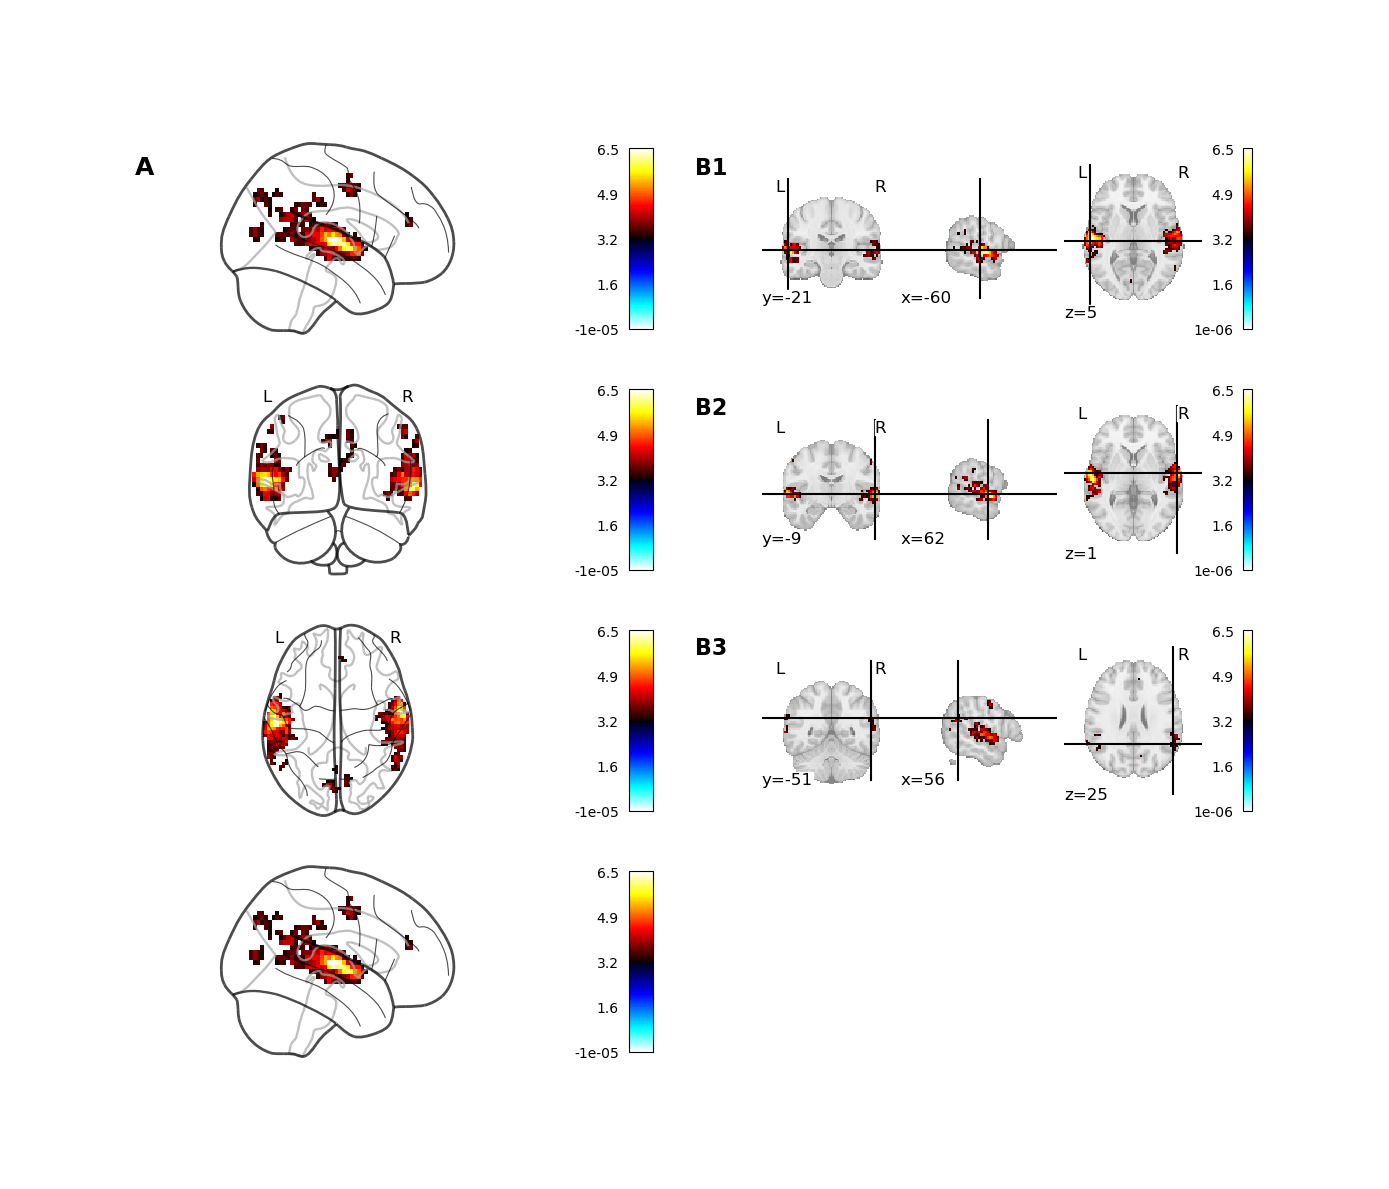

In [48]:
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import label

# --- filtered_img is your already filtered NIfTI ---
# filtered_img = image.load_img("filtered_clusters_5vox.nii.gz")

# --- Label clusters ---
data = filtered_img.get_fdata()
labeled_array, num_features = label(data > 0)

# --- Find the top 3 largest clusters ---
cluster_sizes = [np.sum(labeled_array == i) for i in range(1, num_features + 1)]
largest_idxs = np.argsort(cluster_sizes)[-3:][::-1]  # top 3

# --- Get peak voxel coordinates of these clusters ---
peak_coords = []
for idx in largest_idxs:
    cluster_mask = labeled_array == (idx + 1)
    peak_voxel = np.unravel_index(np.argmax(data * cluster_mask), data.shape)
    peak_coords.append(image.coord_transform(*peak_voxel, filtered_img.affine))

# --- Create figure ---
fig = plt.figure(figsize=(14, 12))  # tall figure for vertical glass brains + 3 slices

# --- Left column: 4 vertically stacked glass brain views ---
glass_views = ['x', 'y', 'z', 'x']  # 4 views
for i, view in enumerate(glass_views):
    ax = fig.add_subplot(4, 2, 2*i+1)  # left column, 4 rows
    plotting.plot_glass_brain(
        filtered_img,
        display_mode=view,
        axes=ax,
        colorbar=True,
        plot_abs=False,
        cmap='cold_hot',
        title=None,        # remove default titles
    )
    ax.set_xticks([])     # remove axis ticks
    ax.set_yticks([])

# --- Right column: top 3 cluster slices ---
for i, coord in enumerate(peak_coords):
    ax = fig.add_subplot(4, 2, 2*i+2)  # right column, 4 rows
    plotting.plot_stat_map(
        filtered_img,
        cut_coords=coord,
        display_mode='ortho',
        colorbar=True,
        cmap='cold_hot',
        axes=ax,
        title=None,  # remove default titles
    )
    ax.set_xticks([])     # remove axis ticks
    ax.set_yticks([])

# --- Add panel labels using fig.text for consistent placement ---
fig.text(0.1, 0.85, "A", fontsize=18, fontweight='bold')  # left column label
fig.text(0.5, 0.85, "B1", fontsize=16, fontweight='bold') # right column top slice
fig.text(0.5, 0.65, "B2", fontsize=16, fontweight='bold') # right column middle slice
fig.text(0.5, 0.45, "B3", fontsize=16, fontweight='bold') # right column bottom slice

plt.tight_layout()
plt.savefig(str(save_dir)+"/glass_brain_vertical_top3_slices.png", dpi=300)
plt.show()

